# Исследовательский анализ факторов, влияющих на дефолт заемщиков в кредитовании
Лизун Артемий - 25.05.2025
### Цель: 
Определить ключевые факторы, способствующие дефолту заемщиков, разработать рекомендации.
### Задачи:
1. Изучить доступные данные, их качество и полноту.
2. Изучить затрагиваемые процессы.
3. Провести разведочный анализ данных для выявления закономерностей и аномалий.
4. Выдвинуть гипотезы о влиянии определенных факторов на вероятность дефолта.
5. Создать визуализации, которые помогут понять связи между факторами и дефолтом заемщиков.
6. Предложить практические рекомендации по внедрению полученных результатов в процесс принятия решений.
### Описание данных:
Датасет Credit Risk Dataset содержит информацию о клиентах банка: 11 факторов, которые могут влиять на кредитный риск, а также информацию случился или не случился дефолт у заёмщика. Данный датасет был взят из открытого источника (https://www.kaggle.com/datasets/laotse/credit-risk-dataset/data) и является имитацией настоящих данных, так как в реальности такая информация конфиденциальна и не подлежит разглашению.   

## Подготовка и обработка данных
### Импортируем библиотеки и загрузим сам датасет

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv('credit.csv')

In [45]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [46]:
print('Первые 5 строк датасета. Названия столбцов превидены к snake_case — это хорошо')
df.head()

Первые 5 строк датасета. Названия столбцов превидены к snake_case — это хорошо


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [47]:
print('Основная информация о датасете.')
print()
df.info()

Основная информация о датасете.

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [48]:
print('Сразу видим нулевые значения, а также неподходящий тип данных.')
print('Количество нулевых значений:')
print()
print(df.isnull().sum())

Сразу видим нулевые значения, а также неподходящий тип данных.
Количество нулевых значений:

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [49]:
df = df.dropna(subset=['person_emp_length', 'loan_int_rate'])
print('Удаляем строки с нулевыми значениями, снова выводим информацию о датасете.')
print()
df.info()

Удаляем строки с нулевыми значениями, снова выводим информацию о датасете.

<class 'pandas.DataFrame'>
Index: 28638 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  28638 non-null  int64  
 1   person_income               28638 non-null  int64  
 2   person_home_ownership       28638 non-null  str    
 3   person_emp_length           28638 non-null  float64
 4   loan_intent                 28638 non-null  str    
 5   loan_grade                  28638 non-null  str    
 6   loan_amnt                   28638 non-null  int64  
 7   loan_int_rate               28638 non-null  float64
 8   loan_status                 28638 non-null  int64  
 9   loan_percent_income         28638 non-null  float64
 10  cb_person_default_on_file   28638 non-null  str    
 11  cb_person_cred_hist_length  28638 non-null  int64  
dtypes: float64(3), int64(5), str

In [50]:
print('Количество дубликатов в данных:', df.duplicated().sum())
print('Удаляем строки с дубликатами')
df = df.drop_duplicates()

Количество дубликатов в данных: 137
Удаляем строки с дубликатами


In [51]:
print ('Меняем тип данных на подходящий для анализа')
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
df['person_home_ownership'] = df['person_home_ownership'].astype('category')
df['loan_intent'] = df['loan_intent'].astype('category')
df['loan_grade'] = df['loan_grade'].astype('category')
df['person_emp_length'] = df['person_emp_length'].astype('int64') 

Меняем тип данных на подходящий для анализа


In [52]:
print('Тип переменных изменен:')
df.info()

Тип переменных изменен:
<class 'pandas.DataFrame'>
Index: 28501 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  28501 non-null  int64   
 1   person_income               28501 non-null  int64   
 2   person_home_ownership       28501 non-null  category
 3   person_emp_length           28501 non-null  int64   
 4   loan_intent                 28501 non-null  category
 5   loan_grade                  28501 non-null  category
 6   loan_amnt                   28501 non-null  int64   
 7   loan_int_rate               28501 non-null  float64 
 8   loan_status                 28501 non-null  int64   
 9   loan_percent_income         28501 non-null  float64 
 10  cb_person_default_on_file   28501 non-null  int64   
 11  cb_person_cred_hist_length  28501 non-null  int64   
dtypes: category(3), float64(2), int64(7)
memory usage: 2.3 MB


In [53]:
print('Выводим описание данных и видим, что max значения возраста, дохода, опыта работы лет нереалистично огромные')
df.describe()

Выводим описание данных и видим, что max значения возраста, дохода, опыта работы лет нереалистично огромные


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,28501.000000,2.850100e+04,28501.000000,28501.000000,28501.000000,28501.000000,28501.000000,28501.000000,28501.000000
mean,27.738676,6.665441e+04,4.790148,9658.533034,11.045385,0.217115,0.169517,0.178590,5.800498
std,6.316166,6.237603e+04,4.157462,6329.604672,3.230748,0.412289,0.106410,0.383016,4.042153
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.950000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,0.000000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,0.000000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


In [54]:
print('Топ 5 самых старых заемщиков:')
oldest = df.sort_values('person_age', ascending=False)['person_age'].head(5)
print(oldest)

Топ 5 самых старых заемщиков:
32297    144
183      144
81       144
575      123
32506     84
Name: person_age, dtype: int64


In [55]:
print('Удаляем всех старше 100 лет')
df = df[df['person_age'] <= 100].copy()
print("Максимальный возраст после очистки:", df['person_age'].max())

Удаляем всех старше 100 лет
Максимальный возраст после очистки: 84


In [56]:
print('Топ 5 наибольше зарабатывающих заемщиков:')
incomest = df.sort_values('person_income', ascending=False)['person_income'].head(5)
print(incomest)
print('Видим, что чрезмерно большие значения удалились вместе с прошлой очисткой, ничего не трогаем')

Топ 5 наибольше зарабатывающих заемщиков:
30049    2039784
32497    1782000
31924    1440000
31922    1362000
17833    1200000
Name: person_income, dtype: int64
Видим, что чрезмерно большие значения удалились вместе с прошлой очисткой, ничего не трогаем


In [57]:
print('Топ 5 наиболее "опытных" заемщиков:')
lengtest = df.sort_values('person_emp_length', ascending=False)['person_emp_length'].head(5)
print(lengtest)

Топ 5 наиболее "опытных" заемщиков:
210      123
0        123
32355     41
32515     38
32428     34
Name: person_emp_length, dtype: int64


In [58]:
print('Удаляем всех у кого стаж работы больше 50 лет')
df = df[df['person_emp_length'] <= 50].copy()
print("Максимальный стаж после очистки:", df['person_emp_length'].max())

Удаляем всех у кого стаж работы больше 50 лет
Максимальный стаж после очистки: 41


In [59]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,28495.000000,2.849500e+04,28495.000000,28495.000000,28495.000000,28495.000000,28495.000000,28495.000000,28495.000000
mean,27.723530,6.643047e+04,4.781751,9657.366205,11.045220,0.217126,0.169517,0.178593,5.800316
std,6.177199,5.151374e+04,4.037958,6327.711290,3.230786,0.412296,0.106379,0.383018,4.040800
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,0.000000,2.000000
25%,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,0.000000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,0.000000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,0.000000,8.000000
max,84.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,1.000000,30.000000


Первичные выводы по описанию данных:
1. 75% заёмщиков до 30 лет при максимальном возрасте в 84.
2. 75% заёмщиков получают до 80.000 при максимальном доходе в 2.000.000.
3. 75% заёмщиков имеют стаж работы до 7 лет при максимальном в 41 год.
4. 75% заёмщиков имеют кредитную историю продолжительностью до 8 лет при максимуме в 30.

Эти выводы дают понять, что датасет имеет большое количество выбросов и аномалий, удаление которых только поможет провести более точный анализ. 

In [60]:
print('Удаляем клиентов старше 35 лет, с доходом выше 100.000$, со стажем работы больше 10 лет и длиной кредитной истории больше 10 лет')
print(f"Исходный размер датасета: {len(df)}")
df = df[
    (df['person_age'] <= 35) & 
    (df['person_income'] <= 100000) & 
    (df['person_emp_length'] <= 10) & 
    (df['cb_person_cred_hist_length'] <= 10)
]

print(f"Размер после фильтрации: {len(df)}")

Удаляем клиентов старше 35 лет, с доходом выше 100.000$, со стажем работы больше 10 лет и длиной кредитной истории больше 10 лет
Исходный размер датасета: 28495
Размер после фильтрации: 20752


In [61]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,20752.000000,20752.000000,20752.000000,20752.000000,20752.000000,20752.000000,20752.000000,20752.000000,20752.000000
mean,25.648178,52744.693379,3.836835,8870.118543,11.045411,0.240073,0.180317,0.179597,4.461209
std,3.543668,21043.255105,2.802698,5665.387927,3.194747,0.427138,0.108260,0.383861,2.417855
min,20.000000,4080.000000,0.000000,500.000000,5.420000,0.000000,0.010000,0.000000,2.000000
25%,23.000000,36000.000000,2.000000,5000.000000,7.900000,0.000000,0.100000,0.000000,3.000000
50%,25.000000,50000.000000,3.000000,7537.500000,10.990000,0.000000,0.160000,0.000000,4.000000
75%,28.000000,68000.000000,6.000000,12000.000000,13.470000,0.000000,0.240000,0.000000,6.000000
max,35.000000,100000.000000,10.000000,35000.000000,22.110000,1.000000,0.830000,1.000000,10.000000


In [62]:
df.info()

<class 'pandas.DataFrame'>
Index: 20752 entries, 1 to 29118
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_age                  20752 non-null  int64   
 1   person_income               20752 non-null  int64   
 2   person_home_ownership       20752 non-null  category
 3   person_emp_length           20752 non-null  int64   
 4   loan_intent                 20752 non-null  category
 5   loan_grade                  20752 non-null  category
 6   loan_amnt                   20752 non-null  int64   
 7   loan_int_rate               20752 non-null  float64 
 8   loan_status                 20752 non-null  int64   
 9   loan_percent_income         20752 non-null  float64 
 10  cb_person_default_on_file   20752 non-null  int64   
 11  cb_person_cred_hist_length  20752 non-null  int64   
dtypes: category(3), float64(2), int64(7)
memory usage: 1.6 MB


**Важное уточнение по объёму выборки.** На предыдущем шаге отсеяны не только аномальные/ошибочные значения (возраст 144 года, стаж работы 123 года — см. выше), но и вполне реальные заёмщики: старше 35 лет, с доходом выше 100 000, со стажем работы больше 10 лет или кредитной историей длиннее 10 лет. Это осознанное сужение выборки, но вместе с ним сократился и её объём (28 495 → 20 752 записей, −27 процентов)
Формально все графики, тесты и итоговые выводы ниже относятся не ко всем заёмщикам банка, а к сегменту сравнительно молодых заёмщиков с доходом до $100K — это стоит держать в уме при чтении рекомендаций, либо ослабить фильтр и оставлять только настоящие выбросы/ошибки данных.

## Визуальный анализ данных

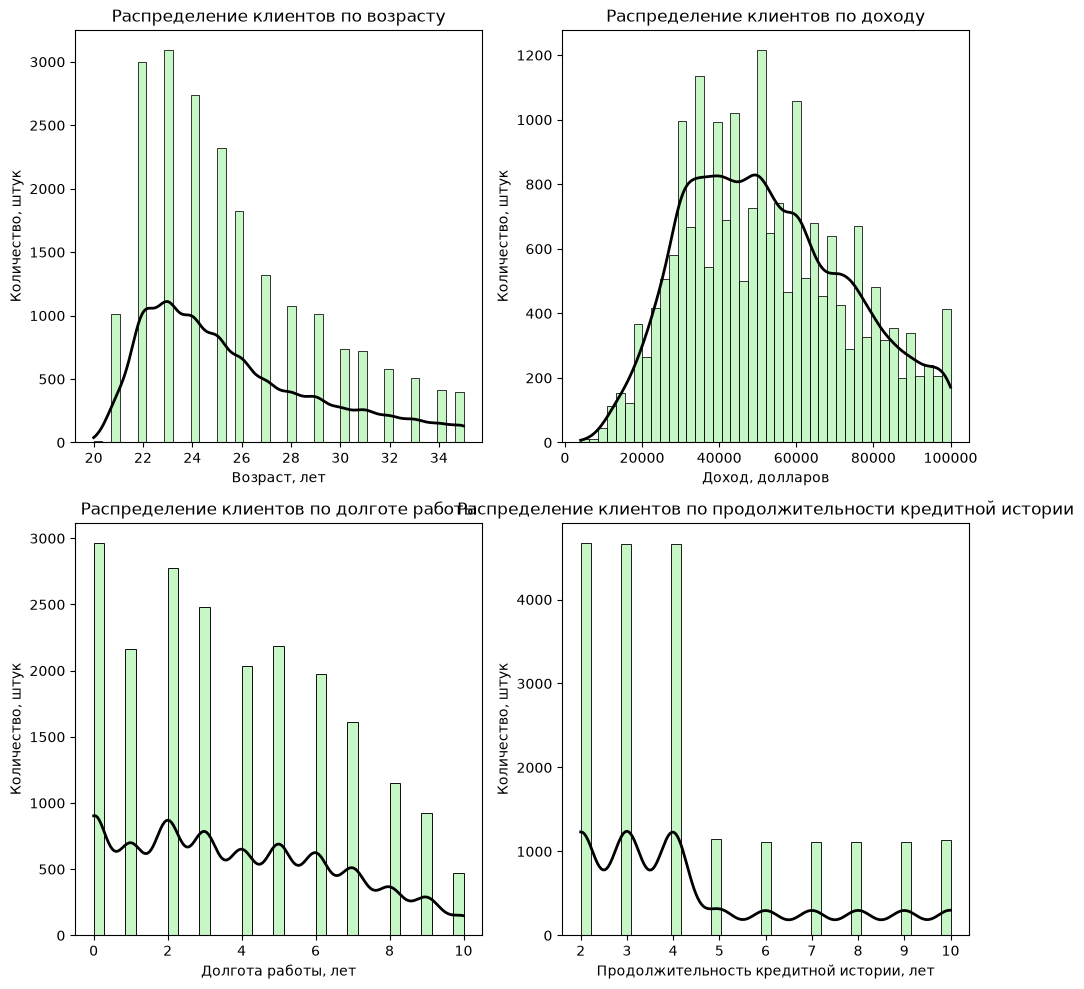

In [63]:
plt.figure(figsize=(10, 10))
plt.subplot(2,2,1)
ax = sns.histplot(df['person_age'], kde=True, color='lightgreen')
ax.lines[0].set_color("black")
ax.lines[0].set_linewidth(2)
plt.title('Распределение клиентов по возрасту')
plt.xlabel('Возраст, лет')
plt.ylabel('Количество, штук')

plt.subplot(2,2,2)
ax = sns.histplot(df['person_income'], kde=True, color='lightgreen')
ax.lines[0].set_color("black")
ax.lines[0].set_linewidth(2)
plt.title('Распределение клиентов по доходу')
plt.xlabel('Доход, долларов')
plt.ylabel('Количество, штук')

plt.subplot(2,2,3)
ax = sns.histplot(df['person_emp_length'], kde=True, color='lightgreen')
ax.lines[0].set_color("black")
ax.lines[0].set_linewidth(2)
plt.title('Распределение клиентов по долготе работы')
plt.xlabel('Долгота работы, лет')
plt.ylabel('Количество, штук')

plt.subplot(2,2,4)
ax = sns.histplot(df['cb_person_cred_hist_length'], kde=True, color='lightgreen')
ax.lines[0].set_color("black")
ax.lines[0].set_linewidth(2)
plt.title('Распределение клиентов по продолжительности кредитной истории')
plt.xlabel('Продолжительность кредитной истории, лет')
plt.ylabel('Количество, штук')

plt.tight_layout()
plt.show()

Пик приходится на 22–23 лет (молодые заёмщики). Распределение ассиметрично вправо.
Доходы распределены равномерно.
Стаж также распеределен равномерно.
Наибольшая продолжительность кредитной истории от 2-4 лет, дальше спад.

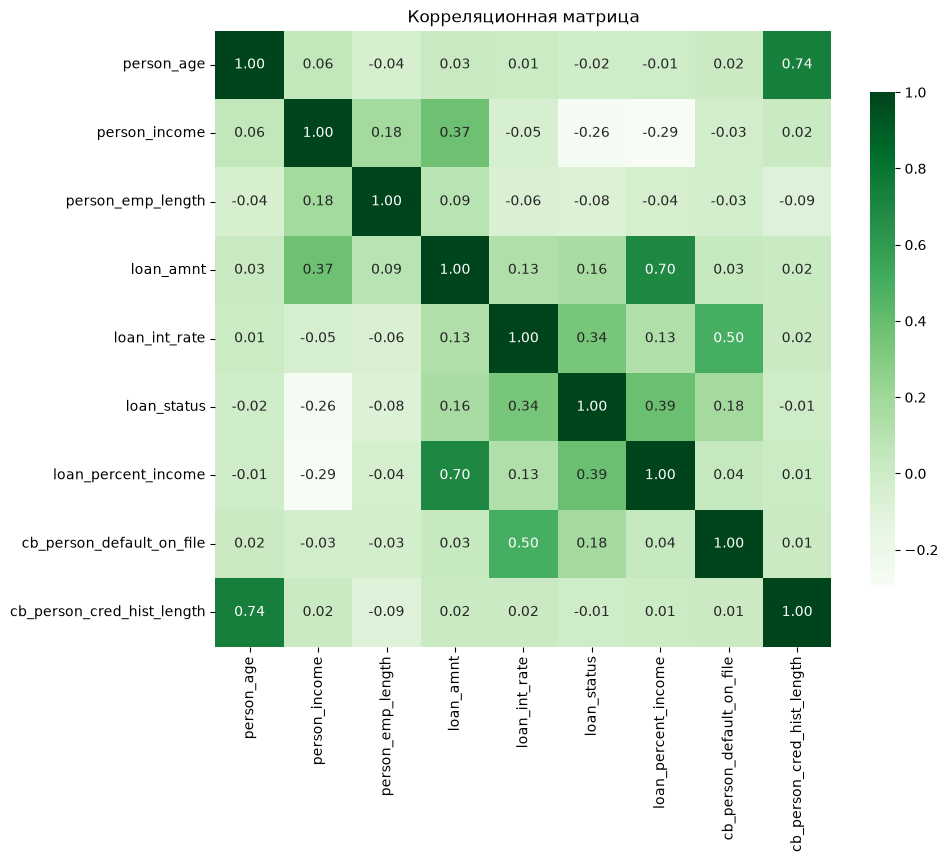

In [64]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='Greens', square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица')
plt.show()

Первичные выводы по поводу дефолта:
1. +0.39	Чем выше доля платежа в доходе, тем чаще дефолт (сильная связь).
2. +0.34	Чем выше процентная ставка, тем чаще дефолт.
3. +0.18	Наличие дефолтов в прошлом увеличивает риск нового.
4. +0.16	Крупные кредиты чаще приводят к дефолту.
5. -0.26	Низкий доход -> выше риск дефолта.

Остальные не влияют.

### Также посмотрим на категориальные переменные. 

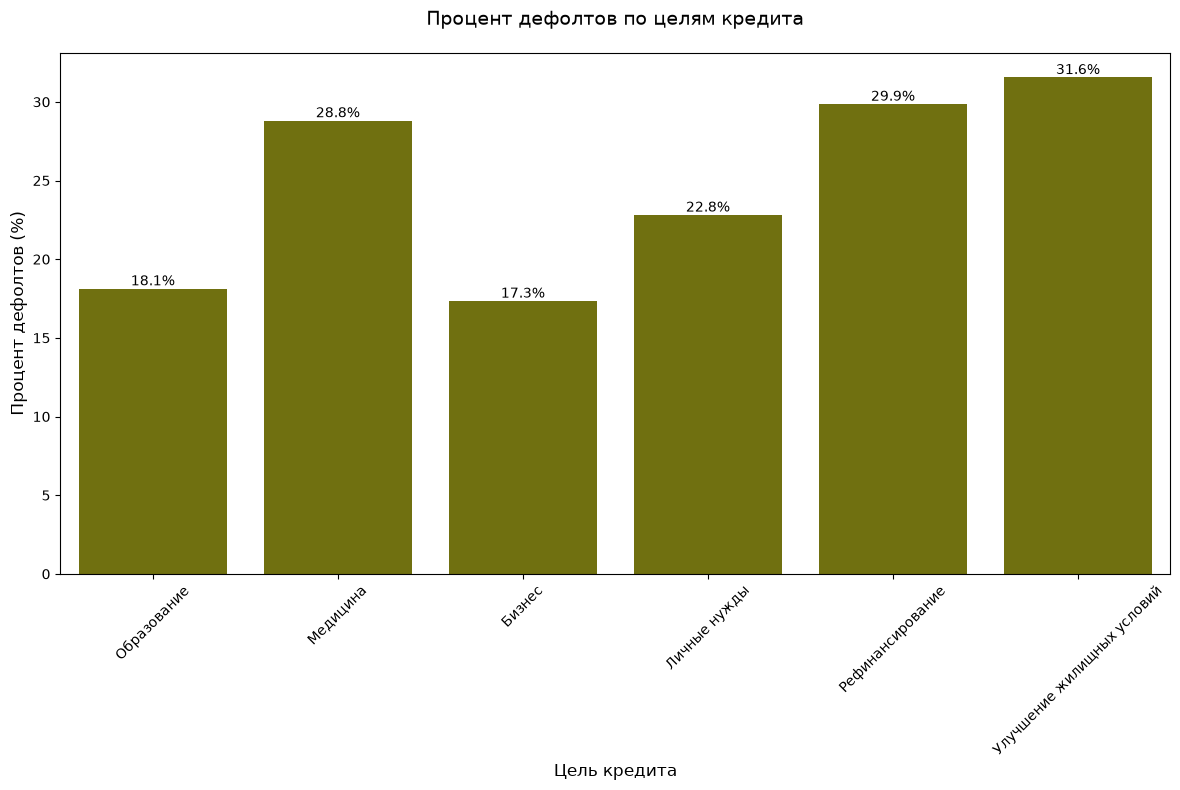

In [65]:
plt.figure(figsize=(12, 8))
sns.barplot(x='loan_intent', y='loan_status', data=df, 
            estimator=lambda x: sum(x)/len(x)*100, 
            color='olive',
            errorbar=None,
            order=['EDUCATION', 'MEDICAL', 'VENTURE', 'PERSONAL', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT'])

plt.title('Процент дефолтов по целям кредита', pad=20, fontsize=14)
plt.ylabel('Процент дефолтов (%)', fontsize=12)
plt.xlabel('Цель кредита', fontsize=12)

plt.xticks(ticks=range(6), 
           labels=['Образование', 'Медицина', 'Бизнес', 'Личные нужды', 'Рефинансирование', 'Улучшение жилищных условий'],
           rotation=45)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%', 
                      (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='center', 
                      xytext=(0, 5), 
                      textcoords='offset points',
                      fontsize=10)

plt.tight_layout()
plt.show()

Люди берущие кредит для улучшения жилищных условий, рефинансирования и медицины чаще всего дефолтятся согласно первичным выводам.

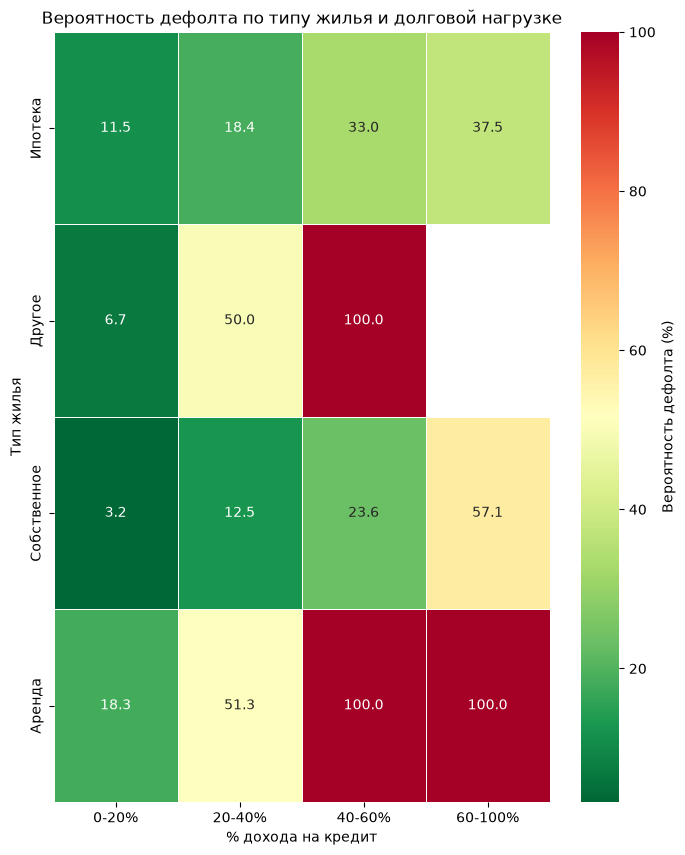

In [66]:
translation = {
    'MORTGAGE': 'Ипотека',
    'RENT': 'Аренда',
    'OWN': 'Собственное',
    'OTHER': 'Другое'
}
df['person_home_ownershipru'] = df['person_home_ownership'].map(translation)
pivot_tableru = df.pivot_table(
    index='person_home_ownershipru',
    columns=pd.cut(df['loan_percent_income'], 
                 bins=[0, 0.2, 0.4, 0.6, 1.0],
                 labels=['0-20%', '20-40%', '40-60%', '60-100%']),
    observed=False,
    values='loan_status', 
    aggfunc='mean'
)

plt.figure(figsize=(8, 10))
sns.heatmap(
    pivot_tableru * 100,
    annot=True, 
    fmt='.1f', 
    cmap='RdYlGn_r', 
    linewidths=0.5,
    cbar_kws={'label': 'Вероятность дефолта (%)'}
)
plt.title('Вероятность дефолта по типу жилья и долговой нагрузке')
plt.xlabel('% дохода на кредит')
plt.ylabel('Тип жилья')
plt.show()

Первичные выводы:
1. Наиболее ненадежные заёмщики в целом — арендаторы или "другое" (40%+ дохода дефолт гарантирован).
2. Наиболее надежные заёмщики в целом — ипотечники.
3. Люди со собственным жильем до 40% дохода на кредит — можно рассмотреть, выше — опасно.

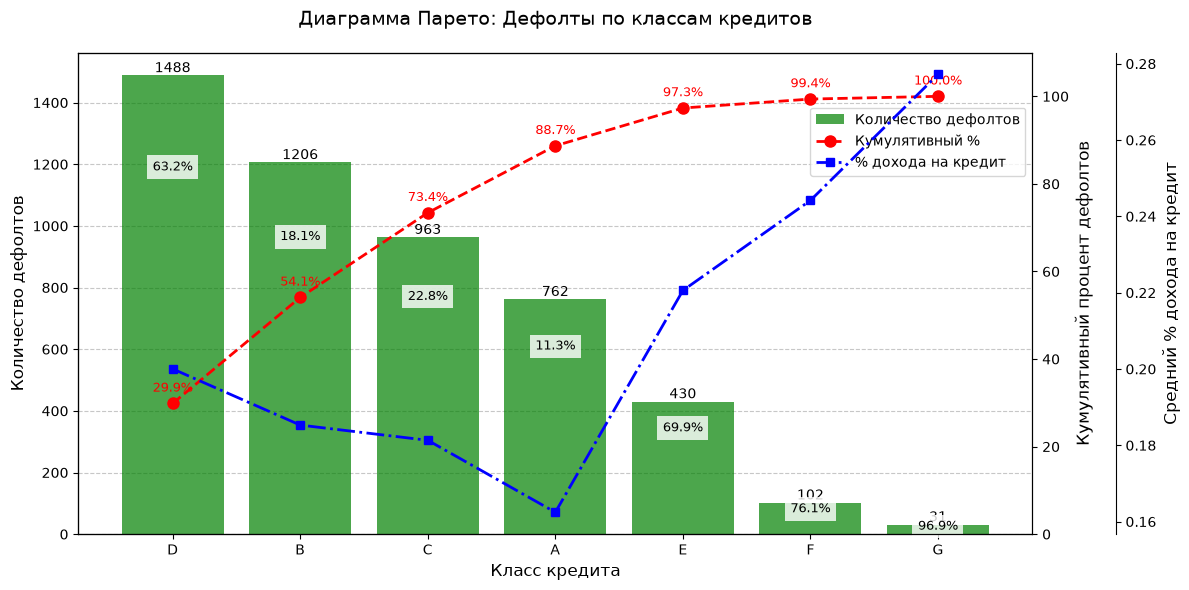

In [67]:
default_counts = df.groupby('loan_grade', observed=False)['loan_status'].sum().sort_values(ascending=False)
total_counts = df['loan_grade'].value_counts().sort_index()
default_rate = (default_counts / total_counts * 100).loc[default_counts.index]
income_percent = df.groupby('loan_grade', observed=False)['loan_percent_income'].mean().loc[default_counts.index]

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(default_counts.index, default_counts.values, 
              color='green', alpha=0.7, label='Количество дефолтов')
ax1.set_xlabel('Класс кредита', fontsize=12)
ax1.set_ylabel('Количество дефолтов', fontsize=12)
ax1.set_title('Диаграмма Парето: Дефолты по классам кредитов', fontsize=14, pad=20)

ax2 = ax1.twinx()
cumulative = default_counts.cumsum() / default_counts.sum() * 100
line = ax2.plot(default_counts.index, cumulative, color='r', marker='o', 
               linestyle='--', linewidth=2, markersize=8, label='Кумулятивный %')
ax2.set_ylim(0, 110)
ax2.set_ylabel('Кумулятивный процент дефолтов', fontsize=12)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
line2 = ax3.plot(default_counts.index, income_percent, color='blue', marker='s', 
                linestyle='-.', linewidth=2, markersize=6, label='% дохода на кредит')
ax3.set_ylabel('Средний % дохода на кредит', fontsize=12)

for i in range(len(default_counts)):
    count = default_counts.iloc[i]
    rate = default_rate.iloc[i]
    cumulative_rate = cumulative.iloc[i]

    ax1.text(i, count, f'{count:.0f}', 
            ha='center', va='bottom', fontsize=10)
    
    ax1.text(i, count * 0.8, f'{rate:.1f}%', 
            ha='center', va='center', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax2.text(i, cumulative_rate + 2, f'{cumulative_rate:.1f}%', 
            ha='center', va='bottom', fontsize=9, color='r')

lines = [bars] + line + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 0.9), fontsize=10)

ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()

Наибольший процент дефолтов у класса кредита D - G (очевидно, поэтому и такой низкий класс).

### Обратим внимание на данные с малой корреляцией в матрице

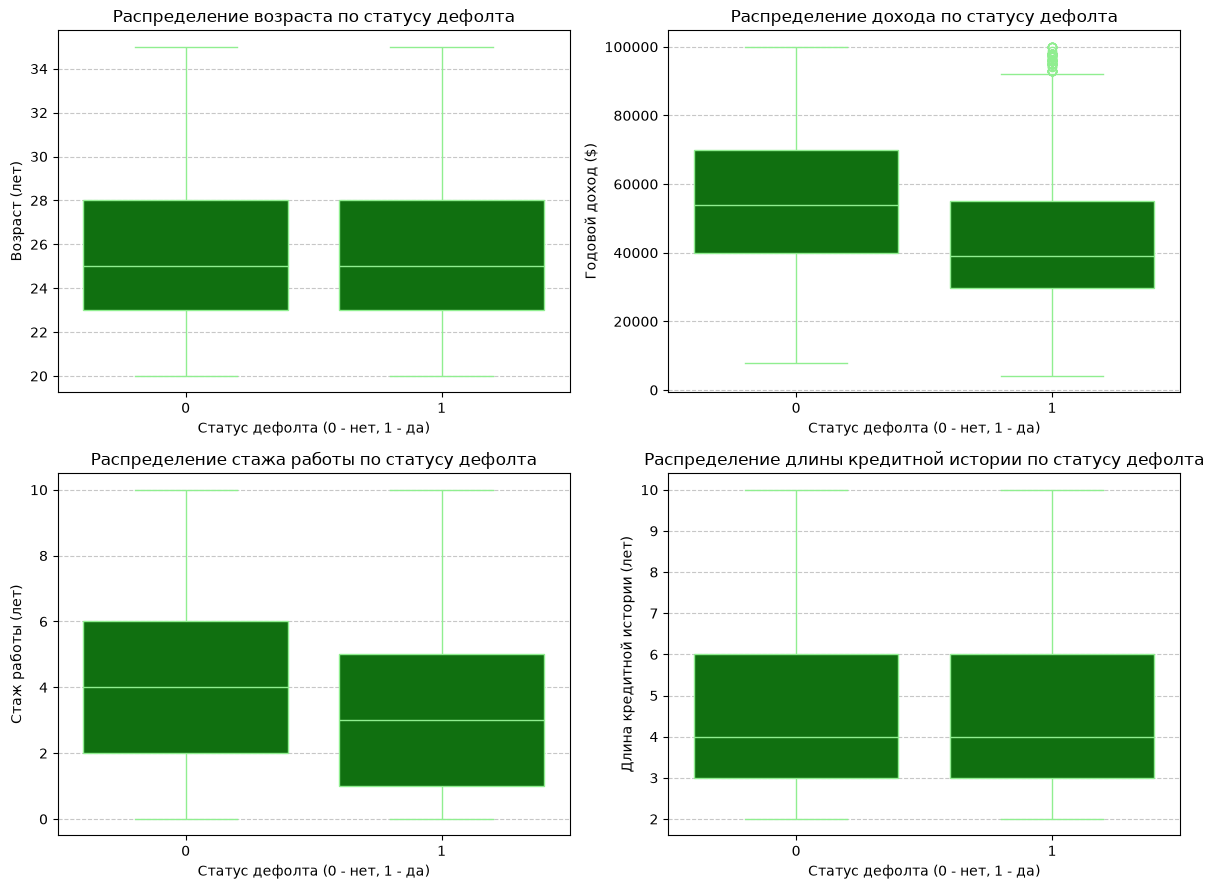

In [68]:
plt.figure(figsize=(12, 9))

plt.subplot(2, 2, 1)
sns.boxplot(x='loan_status', y='person_age', data=df, 
           linecolor='lightgreen', color='green')
plt.title('Распределение возраста по статусу дефолта')
plt.xlabel('Статус дефолта (0 - нет, 1 - да)')
plt.ylabel('Возраст (лет)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 2)
sns.boxplot(x='loan_status', y='person_income', data=df,
           linecolor='lightgreen', color='green')
plt.title('Распределение дохода по статусу дефолта')
plt.xlabel('Статус дефолта (0 - нет, 1 - да)')
plt.ylabel('Годовой доход ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 3)
sns.boxplot(x='loan_status', y='person_emp_length', data=df,
          linecolor='lightgreen', color='green')
plt.title('Распределение стажа работы по статусу дефолта')
plt.xlabel('Статус дефолта (0 - нет, 1 - да)')
plt.ylabel('Стаж работы (лет)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(2, 2, 4)
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df,
           linecolor='lightgreen', color='green')
plt.title('Распределение длины кредитной истории по статусу дефолта')
plt.xlabel('Статус дефолта (0 - нет, 1 - да)')
plt.ylabel('Длина кредитной истории (лет)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

На основе выводов матрицы корреляций выскажем гипотезы.
# Гипотезы
1. Сумма взятая в кредит не оказывает влияние на наличие дефолта.
2. Наличие дефолта в прошлом не влияет на дефолт в будущем.

## Также дополнительные гипотезы по категориальным переменным. 

3. Заемщики с низким кредитным рейтингом получают более высокие процентные ставки, что увеличивает их долговую нагрузку (loan_percent_income) и в итоге приводит к самосбывающемуся прогнозу дефолта
4. Заемщики с длинной кредитной историей (>5 лет) и стажем работы (>3 года) демонстрируют меньший процент дефолтов, даже при низком кредитном рейтинге (D-F)
### Гипотеза №1
H0: Суммая взятая в кредит не оказывает влияние на наличие дефолта.

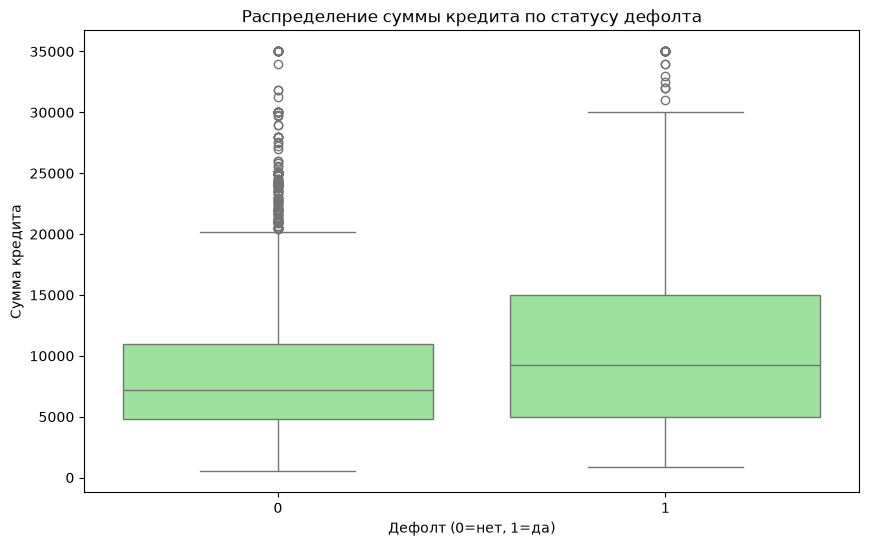

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_amnt', data=df, color = 'lightgreen')
plt.title('Распределение суммы кредита по статусу дефолта')
plt.xlabel('Дефолт (0=нет, 1=да)')
plt.ylabel('Сумма кредита')
plt.show()

In [70]:
from scipy import stats
import numpy as np

default_loans = df[df['loan_status'] == 1]['loan_amnt']
non_default_loans = df[df['loan_status'] == 0]['loan_amnt']

print("Дефолтные кредиты:", len(default_loans))
print("Недефолтные кредиты:", len(non_default_loans))

stat, p = stats.mannwhitneyu(default_loans, non_default_loans, alternative='two-sided')
print("\nРезультаты теста:")
print("p-value:", p)

if p < 0.05:
    print("\nОтвергаем H₀: Сумма кредита значимо влияет на вероятность дефолта (p < 0.05)")
else:
    print("\nНе отвергаем H₀: Нет значимого влияния суммы кредита на дефолт (p >= 0.05)")

Дефолтные кредиты: 4982
Недефолтные кредиты: 15770

Результаты теста:
p-value: 1.549089490200068e-70

Отвергаем H₀: Сумма кредита значимо влияет на вероятность дефолта (p < 0.05)


Результат теста:
U-тест Манна-Уитни показал статистически значимую разницу в сумме кредита между дефолтниками и не-дефолтниками (p-value < 10⁻43).
Практический вывод:
Клиенты, берущие крупные кредиты, существенно чаще допускают дефолт. Рекомендуется ввести лимиты на максимальную сумму кредита для групп риска.


### Гипотеза №2
H0: Наличие дефолта в прошлом не влияет на дефолт в будущем.

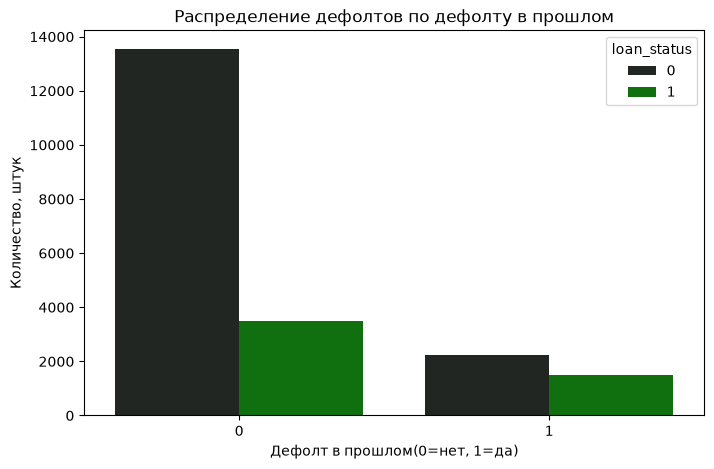

In [71]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='cb_person_default_on_file', 
    hue='loan_status',
    palette='dark:g'
)
plt.xlabel('Дефолт в прошлом(0=нет, 1=да)')
plt.ylabel('Количество, штук')
plt.title("Распределение дефолтов по дефолту в прошлом")
plt.show()


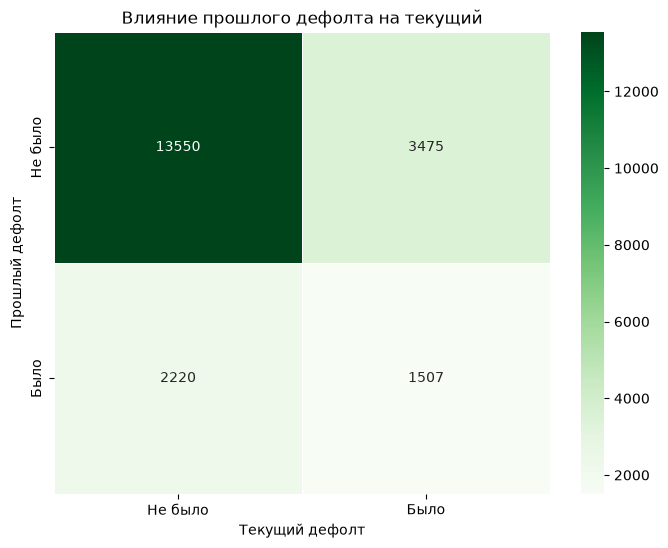

In [72]:
confusion_matrix = pd.crosstab(
    df['cb_person_default_on_file'],  
    df['loan_status'],               
    rownames=['Прошлый дефолт'], 
    colnames=['Текущий дефолт'],
    margins=True  
)

confusion_matrix = confusion_matrix.rename(
    index={0: 'Не было', 1: 'Было'},
    columns={0: 'Не было', 1: 'Было'}
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix.iloc[:-1, :-1], 
    annot=True, 
    fmt='d',
    cmap='Greens',
    linewidths=0.5
)
plt.title("Влияние прошлого дефолта на текущий")
plt.show()

Результаты теста хи-квадрат:
Хи-квадрат = 670.875, p-value = 6.446166631361589e-148

Отношение шансов (OR) = 2.65

Отвергаем H₀: Наличие дефолта в прошлом влияет на дефолт в будущем (p < 0.05)
Клиенты с дефолтом в прошлом в 2.65 раза чаще допускают новый дефолт

Вероятность дефолта:
При наличии прошлого дефолта: 40.4%
Без прошлого дефолта: 20.4%
Разница: 20.0%


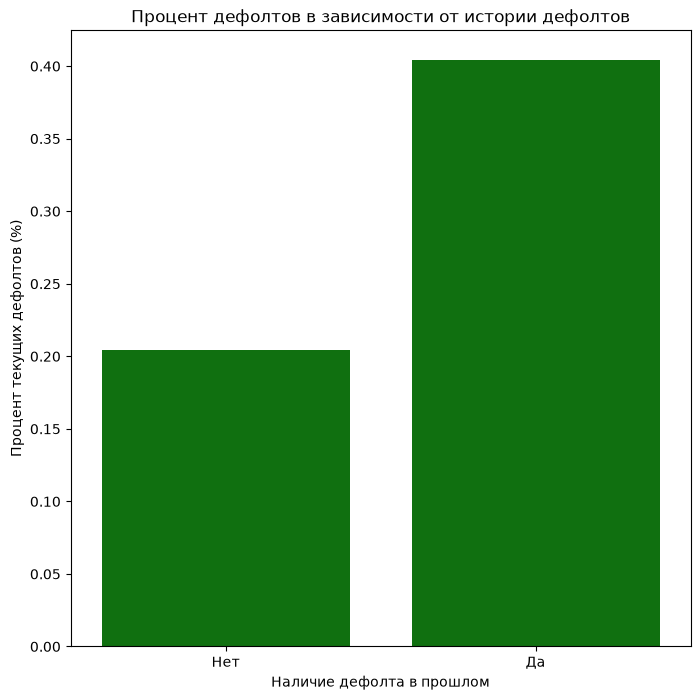

In [73]:
default_history = df['cb_person_default_on_file']  
current_status = df['loan_status']                

defaulters_with_history = current_status[default_history == 1]
defaulters_no_history = current_status[default_history == 0]

contingency_table = pd.crosstab(default_history, current_status)
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Результаты теста хи-квадрат:")
print(f"Хи-квадрат = {chi2:.3f}, p-value = {p}")

odds_ratio = (contingency_table.iloc[1,1] * contingency_table.iloc[0,0]) / \
             (contingency_table.iloc[1,0] * contingency_table.iloc[0,1])

print(f"\nОтношение шансов (OR) = {odds_ratio:.2f}")

if p < 0.05:
    print("\nОтвергаем H₀: Наличие дефолта в прошлом влияет на дефолт в будущем (p < 0.05)")
    print(f"Клиенты с дефолтом в прошлом в {odds_ratio:.2f} раза чаще допускают новый дефолт")
else:
    print("\nНе отвергаем H₀: Нет доказательств влияния прошлых дефолтов (p >= 0.05)")

print("\nВероятность дефолта:")
print(f"При наличии прошлого дефолта: {defaulters_with_history.mean():.1%}")
print(f"Без прошлого дефолта: {defaulters_no_history.mean():.1%}")
print(f"Разница: {defaulters_with_history.mean() - defaulters_no_history.mean():.1%}")

plt.figure(figsize=(8,8))
sns.barplot(x=default_history.map({0: 'Нет', 1: 'Да'}), 
            y=current_status,
            errorbar=None,
            color = 'g'
           )
plt.title('Процент дефолтов в зависимости от истории дефолтов')
plt.xlabel('Наличие дефолта в прошлом')
plt.ylabel('Процент текущих дефолтов (%)')
plt.show()

### Гипотеза №3
H0: Заемщики с низким кредитным рейтингом получают более высокие процентные ставки, что увеличивает их долговую нагрузку (loan_percent_income) и в итоге приводит к самосбывающемуся прогнозу дефолта.

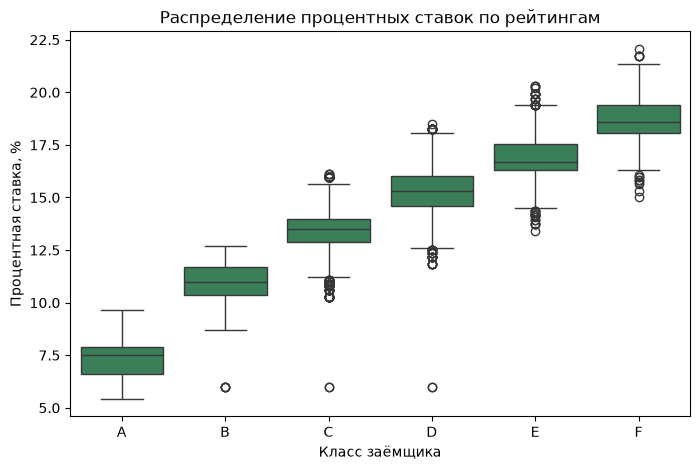

In [74]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_grade', y='loan_int_rate', data=df, order=['A','B','C','D','E','F'], color = 'seagreen')
plt.xlabel('Класс заёмщика')
plt.ylabel('Процентная ставка, %')
plt.title('Распределение процентных ставок по рейтингам')
plt.show()

In [75]:
df['debt_burden'] = df['loan_percent_income'] > 0.3 
pd.crosstab(df['loan_grade'], df['debt_burden'], normalize='index').style.format('{:.1%}')

debt_burden,False,True
loan_grade,,
A,90.5%,9.5%
B,85.2%,14.8%
C,86.9%,13.1%
D,82.9%,17.1%
E,77.9%,22.1%
F,72.4%,27.6%
G,56.2%,43.8%


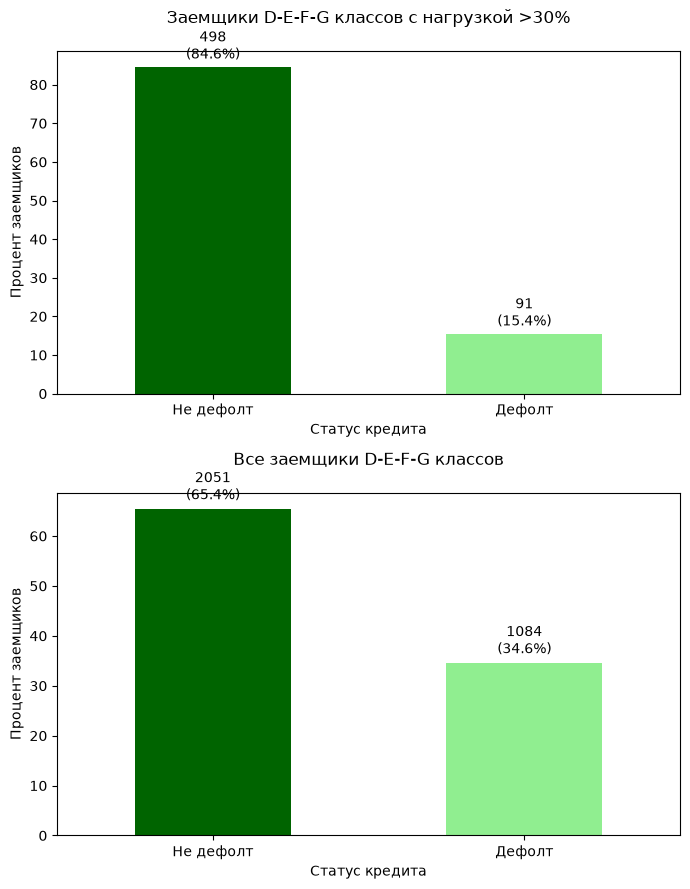

In [76]:
filtered_df = df[(df['loan_grade'].isin(['D', 'E', 'F', 'G'])) & (df['loan_percent_income'] > 0.3)]
default_counts = filtered_df['loan_status'].value_counts()
total_counts = df[df['loan_grade'].isin(['D', 'E', 'F', 'G'])]['loan_status'].value_counts()

filtered_percent = default_counts / default_counts.sum() * 100
total_percent = total_counts / total_counts.sum() * 100

plt.figure(figsize=(7, 9))

plt.subplot(2, 1, 1)
bars1 = filtered_percent.plot(kind='bar', color=['darkgreen', 'lightgreen'])
plt.title('Заемщики D-E-F-G классов с нагрузкой >30%', pad=20)
plt.xlabel('Статус кредита')
plt.ylabel('Процент заемщиков')
plt.xticks(ticks=[0, 1], labels=['Не дефолт', 'Дефолт'], rotation=0)

for i, (count, percent) in enumerate(zip(default_counts, filtered_percent)):
    plt.text(i, percent + 1, f'{count}\n({percent:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.subplot(2, 1, 2)
bars2 = total_percent.plot(kind='bar', color=['darkgreen', 'lightgreen'])
plt.title('Все заемщики D-E-F-G классов', pad=20)
plt.xlabel('Статус кредита')
plt.ylabel('Процент заемщиков')
plt.xticks(ticks=[0, 1], labels=['Не дефолт', 'Дефолт'], rotation=0)

for i, (count, percent) in enumerate(zip(total_counts, total_percent)):
    plt.text(i, percent + 1, f'{count}\n({percent:.1f}%)', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Гипотеза не подтвердилась

### Гипотеза №4
Заемщики с длинной кредитной историей (>5 лет) и стажем работы (>3 года) демонстрируют меньший процент дефолтов, даже при низком кредитном рейтинге (D-F)

Всего высокорисковых заемщиков: 3103
Из них 'стабильных заемщиков': 355

Результаты теста хи-квадрат:
Хи-квадрат = 33.065, p-value = 8.910984606094503e-09
Отношение шансов (OR) = 0.52

Отвергаем H₀: Комбинация длинной кредитной истории и стабильного стажа СНИЖАЕТ вероятность дефолта (p < 0.05)
Стабильные заемщики имеют шансы дефолта в 1.9 раза ниже


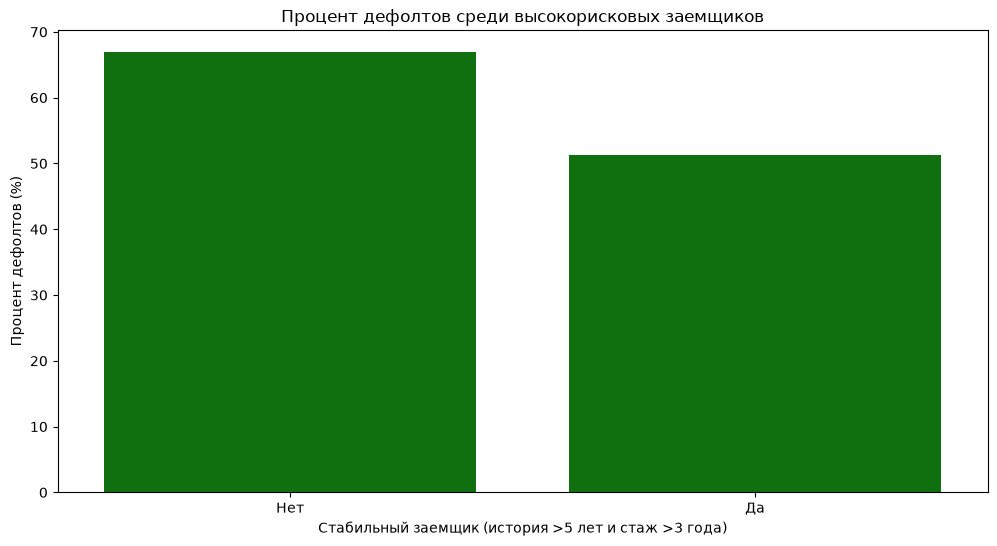

In [77]:
df['long_history'] = df['cb_person_cred_hist_length'] > 5  
df['stable_employment'] = df['person_emp_length'] > 3     
df['high_risk_grade'] = df['loan_grade'].isin(['D','E','F'])
df['stable_borrower'] = df['long_history'] & df['stable_employment']

high_risk_df = df[df['high_risk_grade']]

print("Всего высокорисковых заемщиков:", len(high_risk_df))
print("Из них 'стабильных заемщиков':", high_risk_df['stable_borrower'].sum())
contingency_table = pd.crosstab(high_risk_df['stable_borrower'], 
                               high_risk_df['loan_status'])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
odds_ratio = (contingency_table.iloc[1,1] * contingency_table.iloc[0,0]) / \
             (contingency_table.iloc[1,0] * contingency_table.iloc[0,1])

print("\nРезультаты теста хи-квадрат:")
print(f"Хи-квадрат = {chi2:.3f}, p-value = {p}")
print(f"Отношение шансов (OR) = {odds_ratio:.2f}")

if p < 0.05:
    print("\nОтвергаем H₀: Комбинация длинной кредитной истории и стабильного стажа СНИЖАЕТ вероятность дефолта (p < 0.05)")
    print(f"Стабильные заемщики имеют шансы дефолта в {1/odds_ratio:.1f} раза ниже")
else:
    print("\nНе отвергаем H₀: Нет доказательств влияния этих факторов (p >= 0.05)")

plt.figure(figsize=(12, 6))

sns.barplot(x='stable_borrower', y='loan_status', 
            data=high_risk_df,
            estimator=lambda x: np.mean(x)*100,
            errorbar=None,
           color='g')
plt.title('Процент дефолтов среди высокорисковых заемщиков')
plt.xlabel('Стабильный заемщик (история >5 лет и стаж >3 года)')
plt.ylabel('Процент дефолтов (%)')
plt.xticks([0, 1], ['Нет', 'Да'])
plt.show()


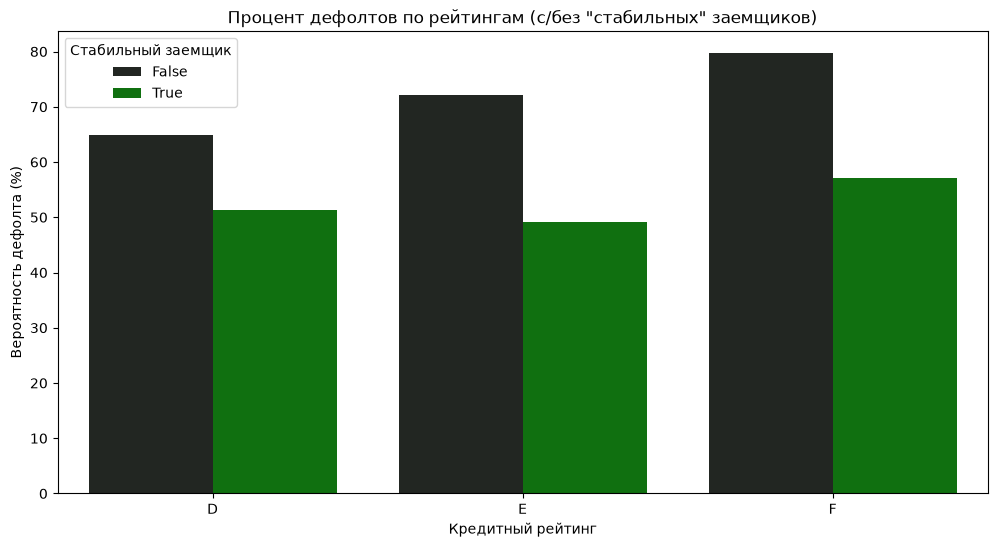

In [78]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x='loan_grade',
    y='loan_status',
    hue='stable_borrower',
    data=df[df['high_risk_grade']],
    estimator=lambda x: sum(x)/len(x)*100,
    order=['D','E','F'],
    palette='dark:g',
     errorbar=None
)
plt.title('Процент дефолтов по рейтингам (с/без "стабильных" заемщиков)')
plt.ylabel('Вероятность дефолта (%)')
plt.xlabel('Кредитный рейтинг')
plt.legend(title='Стабильный заемщик')
plt.show()

Гипотеза подтвердилась

## Итоговые выводы
*(Выводы ниже относятся к сегменту заёмщиков ≤35 лет, с доходом ≤$100K, стажем ≤10 лет и кредитной историей ≤10 лет — см. уточнение по объёму выборки выше.)*

1. Данные были обработаны. Их итоговое количество 20752.
2. Больше всего клиентов имеют возраст 23 года, доход от 30 до 60.000$/год, опыт работы от 0 до 2 лет, а продолжительность кредитной истории до 4 лет.
3. Чем выше доля платежа в доходе, тем чаще дефолт (+0.39). Чем выше процентная ставка, тем чаще дефолт (+0.34).
4. Медицина, улучшение жилищных условий и рефинансирование — потребности, с которых чаще всего не возвращают кредит.
5. Вероятность, что те, кто имеют своё жилье или ипотеку, вернут кредит значительно больше, чем те, кто снимают дом/квартиру в аренду.
6. Пристальное внимание требуется D классу кредита (больше всего дефолтов, больше всего процент дефолтов относительно всех сделок). Также не всегда маленькое кол-во дефолтов, значит что класс хороший (E F G имеют малое кол-во дефолтов, но огромный процент дефолтов к сделкам).
7. Возраст, стаж работы, длина кредитной истории не влияют на дефолт / не дефолт.
8. Чем больше денег берут в кредит, тем меньше вероятность возвращения.
9. Клиенты с дефолтом в прошлом в 2 раза чаще допускают новый дефолт.
10. Заемщики с низким кредитным рейтингом, но большой кредитной историей и стажем, вернут кредит с большей вероятностью, чем просто заёмщики с низким кредитным рейтингом.

# Рекомендации по внедрению системы управления кредитными рисками

## 1. Сегментация клиентов и персонализация условий
   
Реализация:

Внедрить скоринговую модель, учитывающую:

- loan_percent_income (долю платежа в доходе)
- Наличие прошлых дефолтов (cb_person_default_on_file)
- Цель кредита (loan_intent)
- Тип жилья (person_home_ownership)

Пример сегментов:

Низкий риск: Клиенты с ипотекой, доходом >$60K, loan_percent_income < 20%.

Высокий риск: Арендаторы с loan_intent=MEDICAL и прошлыми дефолтами.

Поддержка:

- Автоматическое назначение ставок и лимитов на основе сегмента.
- Регулярный пересмотр критериев (раз в квартал).

## 2. Корректировка кредитной политики
Реализация:

Для D-класса:
- Снизить максимальный loan_percent_income до 25%.
- Требовать поручителя для займов >$10K.

Для E/F/G-классов:
- Уменьшить максимальную сумму кредита на 30%.
- Ввести обязательную страховку кредита.

Для медицинских кредитов:
- Добавить проверку наличия страховки.


# ДОП. Кластеризация данных
"Надежные заемщики": Средний возраст 34 года, малый процент от дохода, малая-средняя сумма кредита, довольно длинная кредитная история

"Рискованная молодежь": Средний возраст 23 года, средний-большой процент от дохода, большая сумма кредита, маленькая кредитная история 

"Средний класс": Близкие к средним значениям по всем параметрам

"Проблемные заемщики": Большой процент от дохода, большая сумма кредита, короткая кредитная история 

In [79]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['person_age', 'loan_percent_income', 'loan_amnt', 'cb_person_cred_hist_length']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

selected_cols = ['person_age', 'loan_percent_income', 'loan_amnt', 'cb_person_cred_hist_length']

df.groupby('cluster')[selected_cols].agg({
    'person_age': ['count', 'mean'],
    'loan_percent_income': 'mean',
    'loan_amnt': 'mean',
    'cb_person_cred_hist_length': 'mean'})

person_age            loan_percent_income     loan_amnt  \
             count       mean                mean          mean   
cluster                                                           
0             9465  23.593344            0.121315   5844.569466   
1             2221  30.009005            0.295484  14925.968032   
2             4755  23.643954            0.296955  14736.009464   
3             4311  30.123637            0.121872   5922.883322   

        cb_person_cred_hist_length  
                              mean  
cluster                             
0                         3.030534  
1                         7.626745  
2                         3.026709  
3                         7.553700

In [80]:
df['cluster_name'] = df['cluster'].astype('str')
replace_dict = {
    0: 'Надежная молодежь',
    1: 'Ненадежное население',
    2: 'Ненадежная молодежь',
    3: 'Надежное население'
}
df['cluster_name'] = df['cluster'].replace(replace_dict)

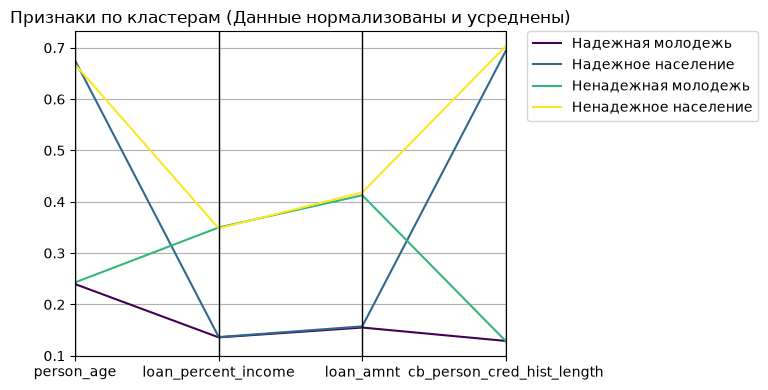

In [81]:
from pandas.plotting import parallel_coordinates

df['cluster_name'] = df['cluster'].replace(replace_dict)

parallel_data = df[['person_age', 'loan_percent_income', 'loan_amnt', 'cb_person_cred_hist_length', 'cluster_name']]

parallel_data_normalized = parallel_data.copy()
for col in ['person_age', 'loan_percent_income', 'loan_amnt', 'cb_person_cred_hist_length']:
    parallel_data_normalized[col] = (parallel_data[col] - parallel_data[col].min()) / (parallel_data[col].max() - parallel_data[col].min())

parallel_data_normalized_grouped = parallel_data_normalized.groupby('cluster_name')\
[['person_age', 'loan_percent_income', 'loan_amnt', 'cb_person_cred_hist_length']].mean().reset_index()

plt.figure(figsize=(6, 4))
parallel_coordinates(parallel_data_normalized_grouped, 'cluster_name', colormap='viridis')
plt.title('Признаки по кластерам (Данные нормализованы и усреднены)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0
)

plt.show()

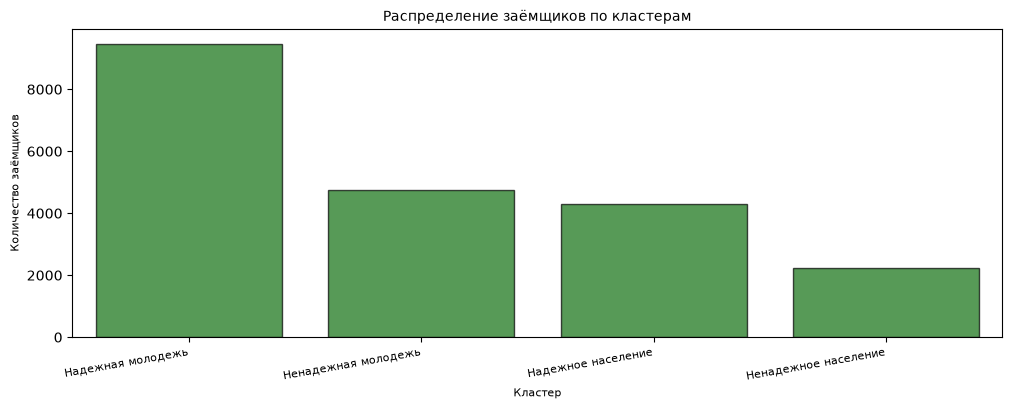

In [82]:
cluster_counts = df['cluster_name'].value_counts().sort_values(ascending=False)

counts_df = cluster_counts.reset_index()
counts_df.columns = ['cluster', 'count'] 

plt.figure(figsize=(12, 4))
sns.barplot(
    x='cluster',
    y='count',  
    data=counts_df,
    color='green', 
    alpha=0.7, 
    edgecolor='black'
)

plt.title('Распределение заёмщиков по кластерам', fontsize=10)
plt.xlabel('Кластер', fontsize=8)
plt.ylabel('Количество заёмщиков', fontsize=8)

plt.xticks(rotation=10, ha='right', fontsize=8)
plt.show()

<Figure size 1200x600 with 0 Axes>

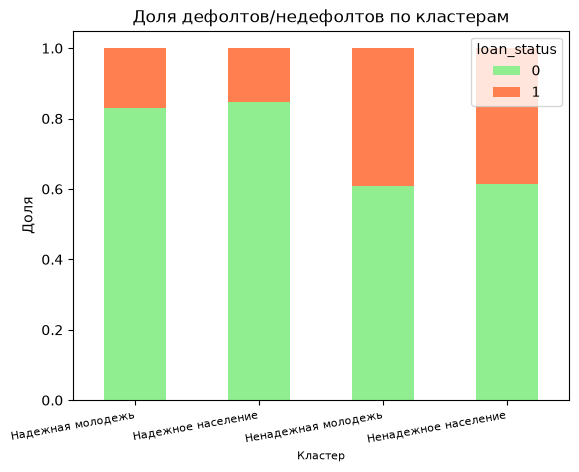

In [83]:
plt.figure(figsize=(12,6))
pd.crosstab(df['cluster_name'], df['loan_status'], normalize='index').plot(
    kind='bar', stacked=True,  
    color=['lightgreen', 'coral'])
plt.title('Доля дефолтов/недефолтов по кластерам')
plt.ylabel('Доля')
plt.xlabel('Кластер', fontsize=8)
plt.xticks(rotation=10, ha='right', fontsize=8)
plt.show()

In [84]:

cluster_stats = df.groupby('cluster_name').agg({
    'person_age': 'mean',
    'loan_percent_income': 'mean',
    'loan_amnt': 'mean',
    'cb_person_cred_hist_length': 'mean',
    'loan_status': lambda x: f"{x.mean()*100:.1f}%",
    'loan_int_rate': 'mean'
}).reset_index()

cluster_counts = df['cluster_name'].value_counts().reset_index()
cluster_counts.columns = ['cluster_name', 'count']  
cluster_stats = cluster_stats.merge(cluster_counts, on='cluster_name')

cluster_stats['Характеристики'] = [
    f"Молодые ({cluster_stats.loc[0, 'person_age']:.1f} лет), низкая нагрузка ({cluster_stats.loc[0, 'loan_percent_income']:.2f}), небольшие кредиты ({cluster_stats.loc[0, 'loan_amnt']:.2f}), короткая кредитная история ({cluster_stats.loc[0, 'cb_person_cred_hist_length']:.1f} лет)",
    f"Средний возраст ({cluster_stats.loc[1, 'person_age']:.1f} лет), низкая нагрузка ({cluster_stats.loc[1, 'loan_percent_income']:.2f}), небольшие кредиты  ({cluster_stats.loc[1, 'loan_amnt']:.2f}), длиная кредитная история ({cluster_stats.loc[1, 'cb_person_cred_hist_length']:.1f} лет)",
    f"Молодые ({cluster_stats.loc[2, 'person_age']:.1f} лет),  серьезная нагрузка ({cluster_stats.loc[2, 'loan_percent_income']:.2f}), большие кредиты ({cluster_stats.loc[2, 'loan_amnt']:.2f}), короткая кредитная история ({cluster_stats.loc[2, 'cb_person_cred_hist_length']:.1f} лет)",
    f"Средний возраст ({cluster_stats.loc[3, 'person_age']:.1f} лет), серьезная нагрузка ({cluster_stats.loc[3, 'loan_percent_income']:.2f}), большие кредиты  ({cluster_stats.loc[3, 'loan_amnt']:.2f}), длиная кредитная история ({cluster_stats.loc[3, 'cb_person_cred_hist_length']:.1f} лет)"
]

cluster_stats['Рекомендации'] = [
    "Увеличить лимиты, предлагать премиальные продукты",
    "Предлагать микрокредиты с коротким сроком, программы лояльности",
    "Пониженные ставки, увеличить срок кредита",
    "Ограничить сумму кредита, требовать поручителя"
]
cluster_stats['loan_status'] = cluster_stats['loan_status'].str.replace('%', '').astype(float) / 100

result_table = cluster_stats[[
    'cluster_name', 'Характеристики', 'loan_status', 
    'loan_int_rate', 'count', 'Рекомендации'
]].rename(columns={
    'cluster_name': 'Имя кластера',
    'loan_status': 'Риск дефолта',
    'loan_int_rate': 'Средняя ставка',
     'count': 'Кол-во' 
})

print("Анализ кластеров и рекомендации:")
display(result_table.style
    .background_gradient(subset=['Риск дефолта'], cmap='Reds')
    .background_gradient(subset=['Средняя ставка'], cmap='Blues')
    .set_properties(**{'text-align': 'left'}))


Анализ кластеров и рекомендации:


,Имя кластера,Характеристики,Риск дефолта,Средняя ставка,Кол-во,Рекомендации
0,Надежная молодежь,"Молодые (23.6 лет), низкая нагрузка (0.12), небольшие кредиты (5844.57), короткая кредитная история (3.0 лет)",0.169000,10.725615,9465,"Увеличить лимиты, предлагать премиальные продукты"
1,Надежное население,"Средний возраст (30.1 лет), низкая нагрузка (0.12), небольшие кредиты (5922.88), длиная кредитная история (7.6 лет)",0.153000,10.845528,4311,"Предлагать микрокредиты с коротким сроком, программы лояльности"
2,Ненадежная молодежь,"Молодые (23.6 лет), серьезная нагрузка (0.30), большие кредиты (14736.01), короткая кредитная история (3.0 лет)",0.392000,11.558768,4755,"Пониженные ставки, увеличить срок кредита"
3,Ненадежное население,"Средний возраст (30.0 лет), серьезная нагрузка (0.30), большие кредиты (14925.97), длиная кредитная история (7.6 лет)",0.387000,11.697163,2221,"Ограничить сумму кредита, требовать поручителя"


**Технический нюанс по кластерам.** Названия кластеров (`replace_dict`) и текстовые описания в итоговой таблице выше присвоены вручную по номеру кластера, который выдал `KMeans`. Эта нумерация не гарантирована при повторном запуске — другая версия `scikit-learn`, другой `random_state` или другой набор данных может привести к тому, что «кластером 0» станет уже другая группа заёмщиков, и тогда текстовые описания перестанут соответствовать реальным данным без какой-либо ошибки выполнения. Для более устойчивого решения стоит формировать описание кластера программно из значений `cluster_stats` (например, по квартилям возраста/долговой нагрузки), а не по жёстко заданному индексу.